# FIXED net test

 - Loads the fixed point network
 - Runs on the validation dataset 
 - Check the accuracy

To check that the accuracy is close to the one obtained with lava FP version

In [1]:
import os, sys
from pathlib import Path
import numpy as np
from lava_network.spiking_dataloader import WISDM_spiking_dataloader, WisdmDatasetParser
from lava_network.output_process import OutputProcess

In [2]:
import json
def deserialize_dict(json_str):
    def convert(obj):
        if isinstance(obj, dict) and 'data' in obj and 'dtype' in obj:
            return np.array(obj['data'], dtype=np.dtype(obj['dtype']))
        if isinstance(obj, list):
            return np.array(obj)
        return obj

    return json.loads(json_str, object_hook=lambda d: {k: convert(v) for k, v in d.items()})


In [4]:
path = f"../data/lava_inhibitory_lif_no_encoder_balanced.json"

with open(path, 'r') as json_file:
    loaded_json_str = json_file.read()
converted_params = deserialize_dict(loaded_json_str)


In [5]:
total_sample = 1000
signal_step = 40
clear_intervall = 4
time_steps = signal_step + clear_intervall

#high score split [0, 2, 6, 8, 9, 14, 17]
#worst score split [0,1,2,5,6,7,12]
# balanced split [0, 1, 4, 8, 9, 10, 14]
dataset = WisdmDatasetParser('../data/data_watch_subset_0_40.npz', norm=None, class_sublset='custom', subset_list= [0, 1, 4, 8, 9, 10, 14] )
val_set = dataset.get_validation_set(shuffle=False, subset=total_sample)
#val_set = dataset.get_test_set(shuffle=False, subset=1000)

num_samples = val_set[0].shape[0]
spiking_loader = WISDM_spiking_dataloader(val_set ,clear_intervall=clear_intervall)
out_sink = OutputProcess(7,num_samples,time_steps, 0)

(6,)
(6,)
ytrain shape (55404, 18)
yval shape (18468, 18)
ytest shape (18469, 18)
num classes train dataset: 7 occurrences of each class:[3127 3066 3044 3047 3150 3087 2973]
num classes eval dataset: 7 occurrences of each class:[1035  968 1048  996 1110 1053 1007]
num classes test dataset: 7 occurrences of each class:[1046 1061 1048 1036 1076 1026  982]


In [6]:
from lava.proc.lif.process import LIF
from lava.proc.dense.process import Dense
from lava.utils.weightutils import SignMode
from lava_network.lif_mod import LIFEncoder
from lava_network.dense_mod import DenseEncoder

# Block structure of the AHPC network
#       +-----------+     +-----------+    +-----------+              +-----------+          +-----------+     +-----------+
# +--+  |           |     |           |    |           |  +--+        |           |          |           |     |           |    +--+
# |i |->|  In_Dense |---->|  In_LIF   |--->|  In_Dense |--| -|------->|  F_LIF    |-------+->| Out_Dense |---->|  O_LIF    |--->|o |
# +--+  |           |     |           |    |           |  +--+        |           |       |  |           |     |           |    +--+
#       +-----------+     +-----------+    +-----------+    A         +-----------+       |  +-----------+     +-----------+
#                                                           |                             |
#                                                           |  +------+ +------+ +------+ |
#                                                           |  |      | |      | |      | |
#                                                           +--|Dense |<| ILIF |<|Dense |<+
#                                                              |      | |      | |      |
#                                                              +------+ +------+ +------+
#

name = "linear1"
linear1_w = np.array(converted_params[name]["weights"])

linear1 = DenseEncoder(weights=linear1_w,
                       num_message_bits=32,
                       name="linear1")

name = "leaky1"

leaky1 = LIFEncoder(shape=(linear1_w.shape[0],),
                    u = np.zeros(linear1_w.shape[0]),
                    v = np.zeros(linear1_w.shape[0]),
                    du = converted_params[name]["du"],
                    dv = converted_params[name]["dv"],
                    vth=converted_params[name]["vth"],
                    log_config=0,
                    name= "leaky1"
                )
linear1.a_out.connect(leaky1.a_in)

name = "linear2"
linear2_w = np.array(converted_params[name]["weights"])
# converted_params[name]["weights"] = linear2_w*2
linear2 = Dense(**converted_params[name],
                sign_mode=SignMode.MIXED,
                name=name)

linear2.s_in.connect_from(leaky1.s_out)

name = "leaky2"
leaky2 = LIF(shape=(linear2_w.shape[0],),
                    **converted_params[name],
                    name= name
                )
#sum.a_out.connect(leaky2.a_in)
linear2.a_out.connect(leaky2.a_in)
#leaky2.a_in.connect_from(linear2.a_out)
name = "recurrent_in"
recurrent_in_weights = np.array(converted_params[name]["weights"])

recurrent_in = Dense(**converted_params[name],
                     name=name)

leaky2.s_out.connect(recurrent_in.s_in)

name = "inibitory_leaky"
ahpc = LIF(shape=(recurrent_in_weights.shape[0],),
                    **converted_params[name],
                    log_config=0,
                    name= name
                )

recurrent_in.a_out.connect(ahpc.a_in)
name = "recurrent_out"
recurrent_out = Dense(**converted_params[name],
                       name=name)
recurrent_out.s_in.connect_from(ahpc.s_out)
recurrent_out.a_out.connect(leaky2.a_in)

name = "linear3"
linear3_w = np.array(converted_params[name]["weights"])
linear3 = Dense(**converted_params[name],
                        name=name)

linear3.s_in.connect_from(leaky2.s_out)
name = "leaky3"
leaky3 = LIF(shape=(linear3_w.shape[0],),
                    **converted_params[name],
                    log_config=0,
                    name= name
                )
leaky3.a_in.connect_from(linear3.a_out)


In [7]:
spiking_loader.data_out.connect(linear1.s_in)
leaky3.s_out.connect(out_sink.spikes_in)
out_sink.label_in.connect_from(spiking_loader.label_out)

In [8]:

from lava.magma.core.run_conditions import RunSteps
from lava.magma.core.run_configs import Loihi1SimCfg, Loihi2SimCfg
import numpy as np
from tqdm import tqdm

# timesteps = 40 + 4 (40 + num of layers)
clock = tqdm(range(num_samples))
for _, i in enumerate(clock):
      out_sink.run(condition=RunSteps(num_steps=time_steps),
                  run_cfg=Loihi1SimCfg(select_sub_proc_model=True,
                  select_tag='fixed_pt'))

      # Reset the state of the network every segment
      leaky1.v.set(np.zeros(leaky1.v.shape))
      leaky1.u.set(np.zeros(leaky1.u.shape))
      leaky2.v.set(np.zeros(leaky2.v.shape))
      leaky2.u.set(np.zeros(leaky2.u.shape))
      leaky3.v.set(np.zeros(leaky3.v.shape))
      leaky3.u.set(np.zeros(leaky3.u.shape))
      ahpc.v.set(np.zeros(ahpc.v.shape))
      ahpc.u.set(np.zeros(ahpc.u.shape))
      linear1.a_buff.set(np.zeros(linear1.a_buff.shape))
      linear2.a_buff.set(np.zeros(linear2.a_buff.shape))
      linear3.a_buff.set(np.zeros(linear3.a_buff.shape))
      recurrent_in.a_buff.set(np.zeros(recurrent_in.a_buff.shape))
      recurrent_out.a_buff.set(np.zeros(recurrent_out.a_buff.shape))

      tmp_predicition = out_sink.pred_labels.get().astype(int)
      current_accuracy = np.sum((tmp_predicition[:i] == val_set[1][:i])/(i+1))*100
      clock.set_description(f"Current accuracy: {current_accuracy:.4f}")
# Stop the execution
out_sink.stop()
# 79.4000 with linear2*1.2
# 85.8000 with linear2*2
print(f"Final accuracy: {current_accuracy:.4f}")


Current accuracy: 95.4000: 100%|██████████| 1000/1000 [02:26<00:00,  6.85it/s]

Final accuracy: 95.4000


In [8]:

# from lava.magma.core.run_conditions import RunSteps
# from lava.magma.core.run_configs import Loihi1SimCfg, Loihi2SimCfg
# import numpy as np
# from tqdm import tqdm


# out_sink.run(condition=RunSteps(num_steps=time_steps*num_samples),
#             run_cfg=Loihi1SimCfg(select_sub_proc_model=True,
#             select_tag='fixed_pt'))

# i = num_samples
# tmp_predicition = out_sink.pred_labels.get().astype(int)
# current_accuracy = np.sum((tmp_predicition[:i] == val_set[1][:i])/(i+1))*100


# out_sink.stop()

# print(f"Final accuracy: {current_accuracy:.4f}")


[2 4 0 3 5 0 0 0 3 3 1 5 0 4 2 1 5 1 6 5 3 1 4 4 4 0 4 5 3 2 2 3 0 3 1 1 5 4 2 4 4 3 3 1 5 0 5 1 2 2 3 0 2 6 2 1 2 4 1 5 2 1 3 3 5 1 0 4 4 6 4 4 2 0 1 3 0 4 6 0 2 4 4 2 5 6 6 5 2 0 0 6 0 0 0 3 5 1 0 1]
[2 4 0 3 5 0 0 0 3 3 1 5 0 4 2 1 5 1 6 6 6 0 4 6 4 0 4 5 3 2 2 6 0 3 1 1 5 4 2 6 4 6 3 1 5 0 5 4 2 2 6 0 2 6 2 1 2 4 1 5 2 5 3 3 5 1 1 4 4 6 4 4 2 0 1 3 0 4 6 0 2 4 4 1 5 6 5 5 6 0 0 6 0 0 0 3 5 1 0 1]


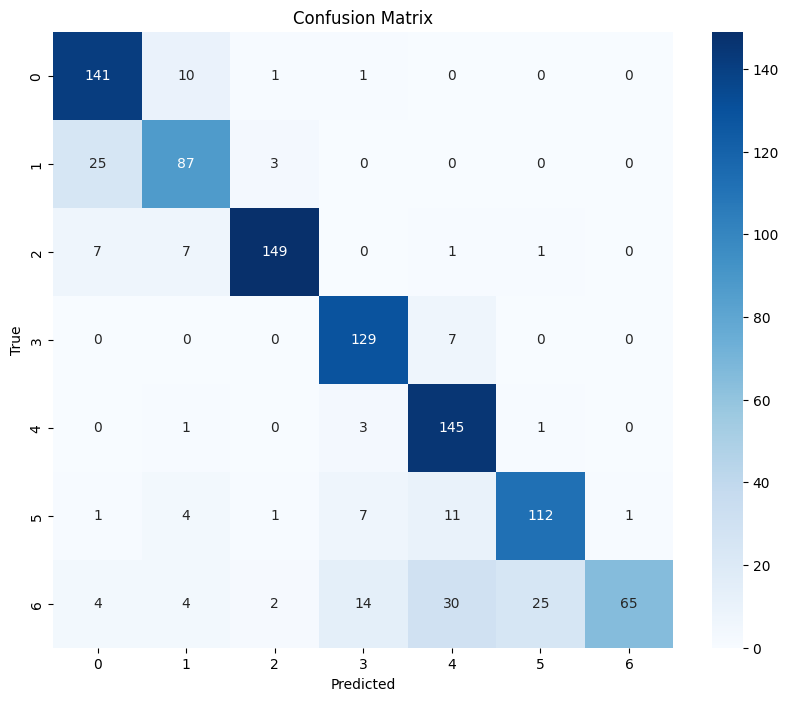

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

print(tmp_predicition[:100])
print(val_set[1][:100])
import matplotlib.pyplot as plt

# Calculate confusion matrix
conf_matrix = confusion_matrix(val_set[1], tmp_predicition)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def gen_confusion_matrix(predictions, labels, path):

    num_label = max(labels)
    #print(f'prediction shape {predictions.shape} and labels shape{len(labels)}')
    conf_matrix = confusion_matrix(predictions, labels)
    # Plot confusion matrix using Seaborn
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=range(num_label),
                yticklabels=range(num_label))

    plt.title('Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')

    # Save the plot
    file_path = os.path.join(path,'confusion_matrix.png')
    plt.savefig(file_path, bbox_inches='tight')


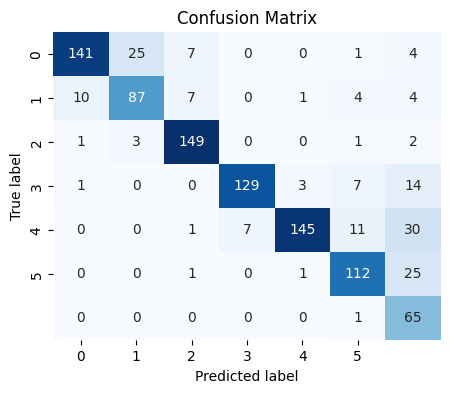

In [11]:
gen_confusion_matrix(tmp_predicition, val_set[1], '../data/')

In [12]:
def get_indices_for_class(actual_labels, predicted_labels, true_class_index, predicted_class_index):
    indices = []
    for i, (true_label, predicted_label) in enumerate(zip(actual_labels, predicted_labels)):
        if true_label == true_class_index and predicted_label == predicted_class_index:
            indices.append(i)
    return indices

# Example usage:
actual_labels = val_set[1]
predicted_labels = tmp_predicition
true_class_index = 1
predicted_class_index = 0

indices = get_indices_for_class(actual_labels, predicted_labels, true_class_index, predicted_class_index)
print(indices)

[66, 106, 118, 193, 214, 238, 268, 269, 307, 321, 360, 364, 373, 420, 456, 460, 474, 698, 775, 792, 851, 901, 953, 956, 974]


In [13]:
def find_misclassified_indexes(true_labels, predicted_labels, target_class):
    """
    Find all indexes where the objects of the given class are misclassified.

    Parameters:
    true_labels (list or np.array): Array of true labels.
    predicted_labels (list or np.array): Array of predicted labels.
    target_class (int or str): The class label to find misclassifications for.

    Returns:
    list: List of indexes where the objects of the given class are misclassified.
    """
    misclassified_indexes = [index for index, (true, pred) in enumerate(zip(true_labels, predicted_labels)) if true == target_class and true != pred]
    return misclassified_indexes

# Example usage
true_labels = actual_labels
predicted_labels = tmp_predicition
target_class = 1
result = find_misclassified_indexes(true_labels, predicted_labels, target_class)
print(result)  # Output: [1, 6]

[66, 83, 106, 118, 149, 193, 214, 238, 268, 269, 307, 321, 360, 364, 373, 414, 420, 456, 460, 474, 698, 775, 792, 851, 901, 953, 956, 974]
